# Customer Segmentation Using Unsupervised Learning

**Objective:** Cluster customers based on spending habits and propose marketing strategies for each segment.

## Problem Statement
A mall wants to understand its customers better. By grouping similar customers together, the marketing team can create targeted campaigns. We will use K-Means Clustering to find these groups and visualize them using PCA.


## 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shutil

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

%matplotlib inline
print("Libraries imported.")


Libraries imported.


## 2: Load the Dataset

In [2]:
import kagglehub

path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")
print("Downloaded to:", path)

# Copy files to current folder so pandas can find them
for f in os.listdir(path):
    shutil.copy(os.path.join(path, f), f)
    print("Copied:", f)

Using Colab cache for faster access to the 'customer-segmentation-tutorial-in-python' dataset.
Downloaded to: /kaggle/input/customer-segmentation-tutorial-in-python
Copied: Mall_Customers.csv


In [3]:
df = pd.read_csv('Mall_Customers.csv')
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 3: Dataset Understanding

In [4]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())


Shape: (200, 5)

Columns: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Missing values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## 4: Exploratory Data Analysis (EDA)

/tmp/ipykernel_4680/4180209788.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Gender', palette='Set2')


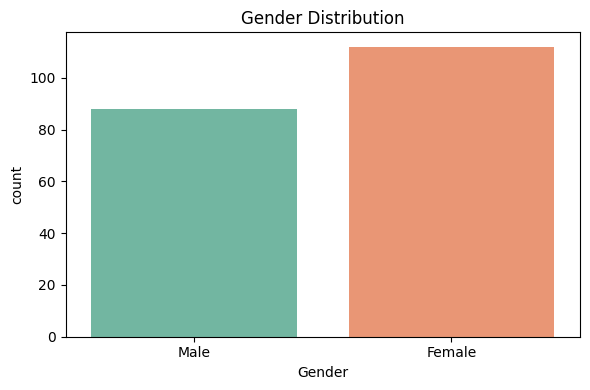

In [6]:
# Gender distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Gender', palette='Set2')
plt.title('Gender Distribution')
plt.tight_layout()
plt.show()


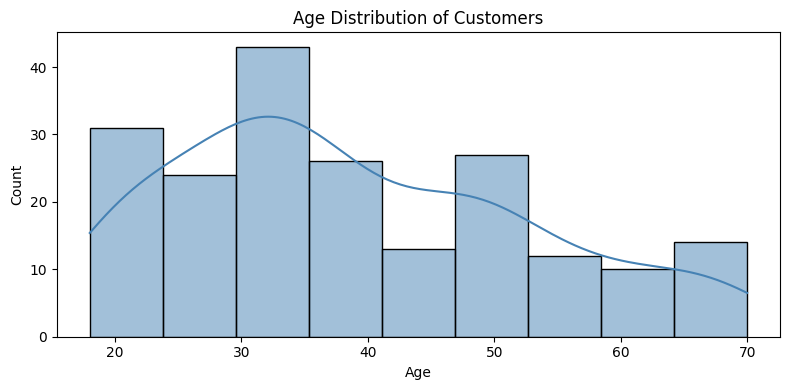

In [7]:
# Age distribution
plt.figure(figsize=(8,4))
sns.histplot(df['Age'], kde=True, color='steelblue')
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.tight_layout()
plt.show()


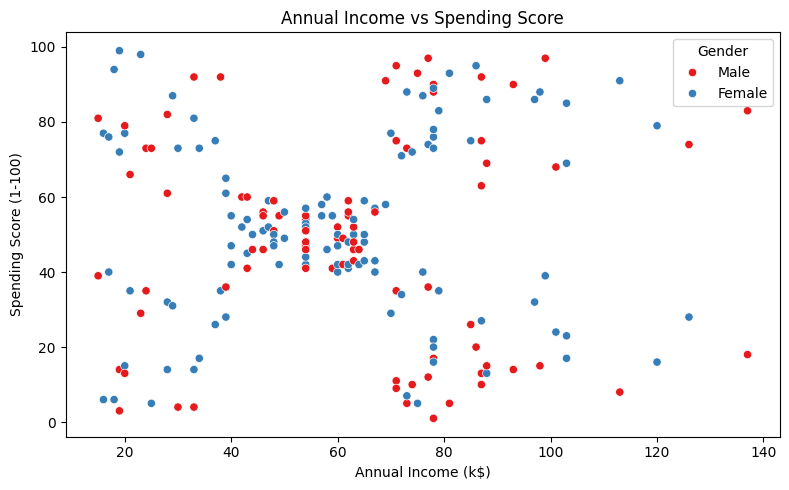

In [8]:
# Annual Income vs Spending Score — main clustering features
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Gender', palette='Set1')
plt.title('Annual Income vs Spending Score')
plt.tight_layout()
plt.show()


## 5: Data Preparation

In [9]:
# Use Annual Income and Spending Score for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scale so both columns are on the same range
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data scaled and ready.")


Data scaled and ready.


## 6: Finding Optimal Clusters — Elbow Method

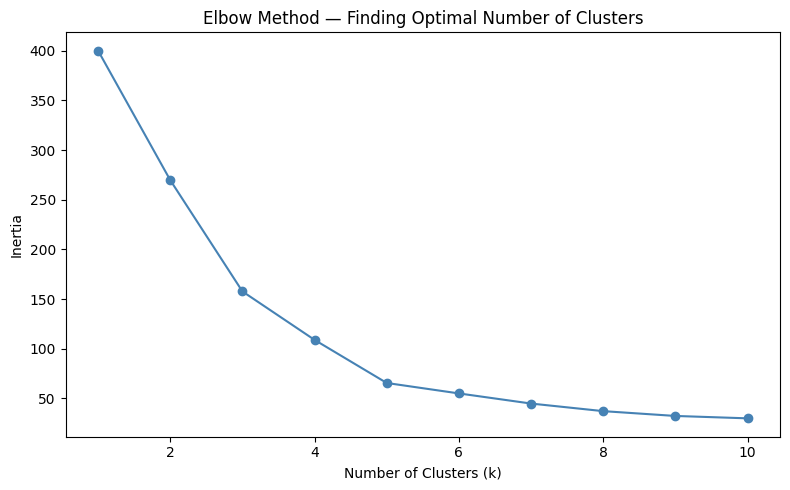

In [10]:
# Run KMeans for k=1 to k=10 and record the inertia each time
# Inertia = total distance of points from their cluster center
# Lower inertia = tighter clusters, but too many clusters = overfitting

inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), inertia, marker='o', color='steelblue')
plt.title('Elbow Method — Finding Optimal Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()


## 7: Apply K-Means Clustering

In [11]:
# k=5 is the optimal value for this dataset (visible in the elbow plot)
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("Customers per cluster:")
print(df['Cluster'].value_counts().sort_index())


Customers per cluster:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


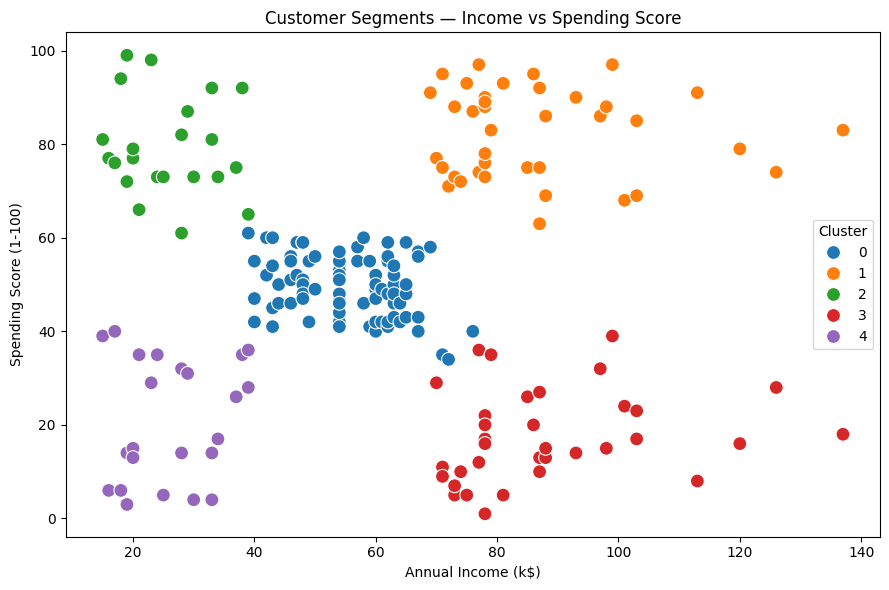

In [12]:
# Plot the clusters on original feature space
plt.figure(figsize=(9,6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Cluster', palette='tab10', s=100)
plt.title('Customer Segments — Income vs Spending Score')
plt.tight_layout()
plt.show()


## 8: PCA Visualization

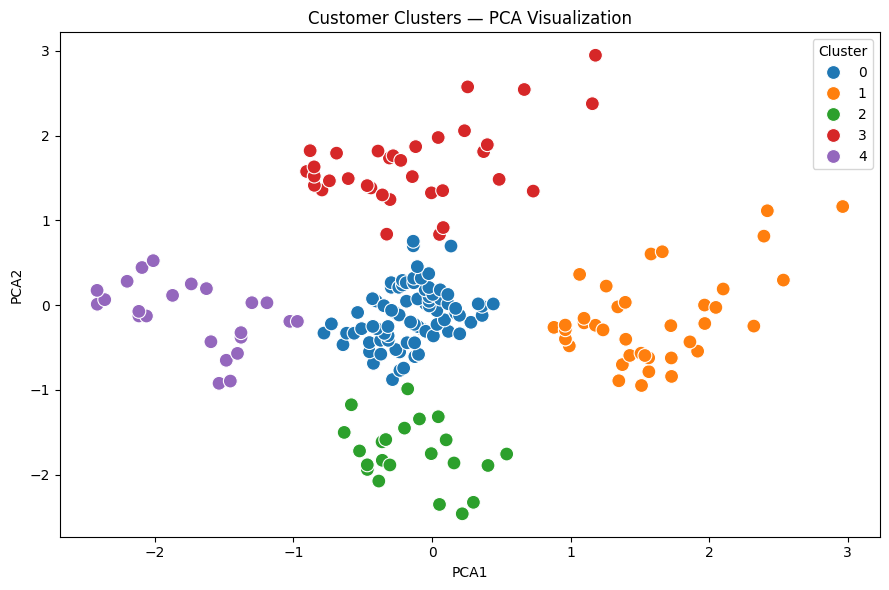

In [13]:
# PCA compresses the scaled data into 2 dimensions so we can plot it
# Even if we had 10 features, PCA lets us see clusters in 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])
pca_df['Cluster'] = df['Cluster']

plt.figure(figsize=(9,6))
sns.scatterplot(data=pca_df, x='PCA1', y='PCA2', hue='Cluster', palette='tab10', s=100)
plt.title('Customer Clusters — PCA Visualization')
plt.tight_layout()
plt.show()


## 9: Cluster Profiles

In [14]:
# Average values per cluster to understand each segment
cluster_summary = df.groupby('Cluster')[['Age','Annual Income (k$)','Spending Score (1-100)']].mean().round(1)
print(cluster_summary)


          Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                  
0        42.7                55.3                    49.5
1        32.7                86.5                    82.1
2        25.3                25.7                    79.4
3        41.1                88.2                    17.1
4        45.2                26.3                    20.9


## Conclusion

Five customer segments were identified using K-Means Clustering:

| Cluster | Income | Spending | Profile | Marketing Strategy |
|---------|--------|----------|---------|-------------------|
| 0 | Low | Low | Budget-conscious | Discount offers, value deals |
| 1 | Low | High | Impulsive spenders | Loyalty rewards, flash sales |
| 2 | Medium | Medium | Average shoppers | General promotions |
| 3 | High | Low | Careful high earners | Premium quality messaging |
| 4 | High | High | Ideal customers | VIP programs, exclusive offers |

**Key insight:** Cluster 4 (high income, high spending) is the most valuable group. Cluster 3 (high income, low spending) has the most untapped potential. Cluster 1 is a risk — low income but high spending may not be sustainable.
